In [1]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def calculate_radial_avg(data, nbins=500):
    '''
    Load the intensity of run and calculate the aziumuthal integration
    '''

    #xy position of the pixels (from dragonfly)
    coords_xy = np.load('./data/coords_xy.npy')
    #mask for the detector
    raw_mask = np.load('./data/raw_mask.npy')

    #radius from center position
    det_r = np.sqrt(coords_xy[0]**2 + coords_xy[1]**2).ravel()
    
    rbins = np.linspace(det_r.min(), det_r.max(), nbins) #bin positions
    det_r_ind = np.digitize(det_r, rbins) #the index where each pixel in the detector should go

    
    mymask = np.zeros_like(raw_mask)
    mymask[raw_mask>0] = 1
    mymask[data.ravel()==0] = 1
    
    ngpix = np.zeros(nbins+1) #init array for number of good pixels in a radial ring
    np.add.at(ngpix, det_r_ind, (mymask ==0)) #count the number pixels that are good in each radial ring


    radavg = np.zeros_like(ngpix) #init array for the radial average
    np.add.at(radavg, det_r_ind,  (mymask==0)*data.ravel()) #add the intensty values at each position
    radavg /= ngpix #divide by the number of good pixels

    vminusq = np.zeros_like(data).ravel()
    
    for val in np.unique(det_r_ind):
        vminusq[det_r_ind==val] = (data.ravel()[det_r_ind==val] - radavg[val])**2
        
    radstd = np.zeros_like(ngpix) #init array for the radial average
    np.add.at(radstd, det_r_ind,  (mymask==0)*vminusq) #add the intensty values at each position
    radstd /= ngpix #divide by the number of good pixels
    radstd = np.sqrt(radstd)
    
    return rbins, radavg, radstd, ngpix, det_r_ind, mymask

def save_radavg(run_number):
    with h5py.File(f'./data/r0{run_number}_sel_gain.h5', 'r') as f:
        inte = f['/data/data'][...]

    rbins, radavg, radstd, ngpix, det_r_ind, mymask = calculate_radial_avg(inte, nbins=500)
        
    with h5py.File(f'./data/radav-r{run_number}.h5', 'w') as f:
        f['/rbins'] = rbins
        f['/radavg'] = radavg
        f['/radstd'] = radstd
        f['/ngpix'] = ngpix
        

run_numbers = [571, 572,  574]
for run_number in run_numbers:
    save_radavg(run_number)

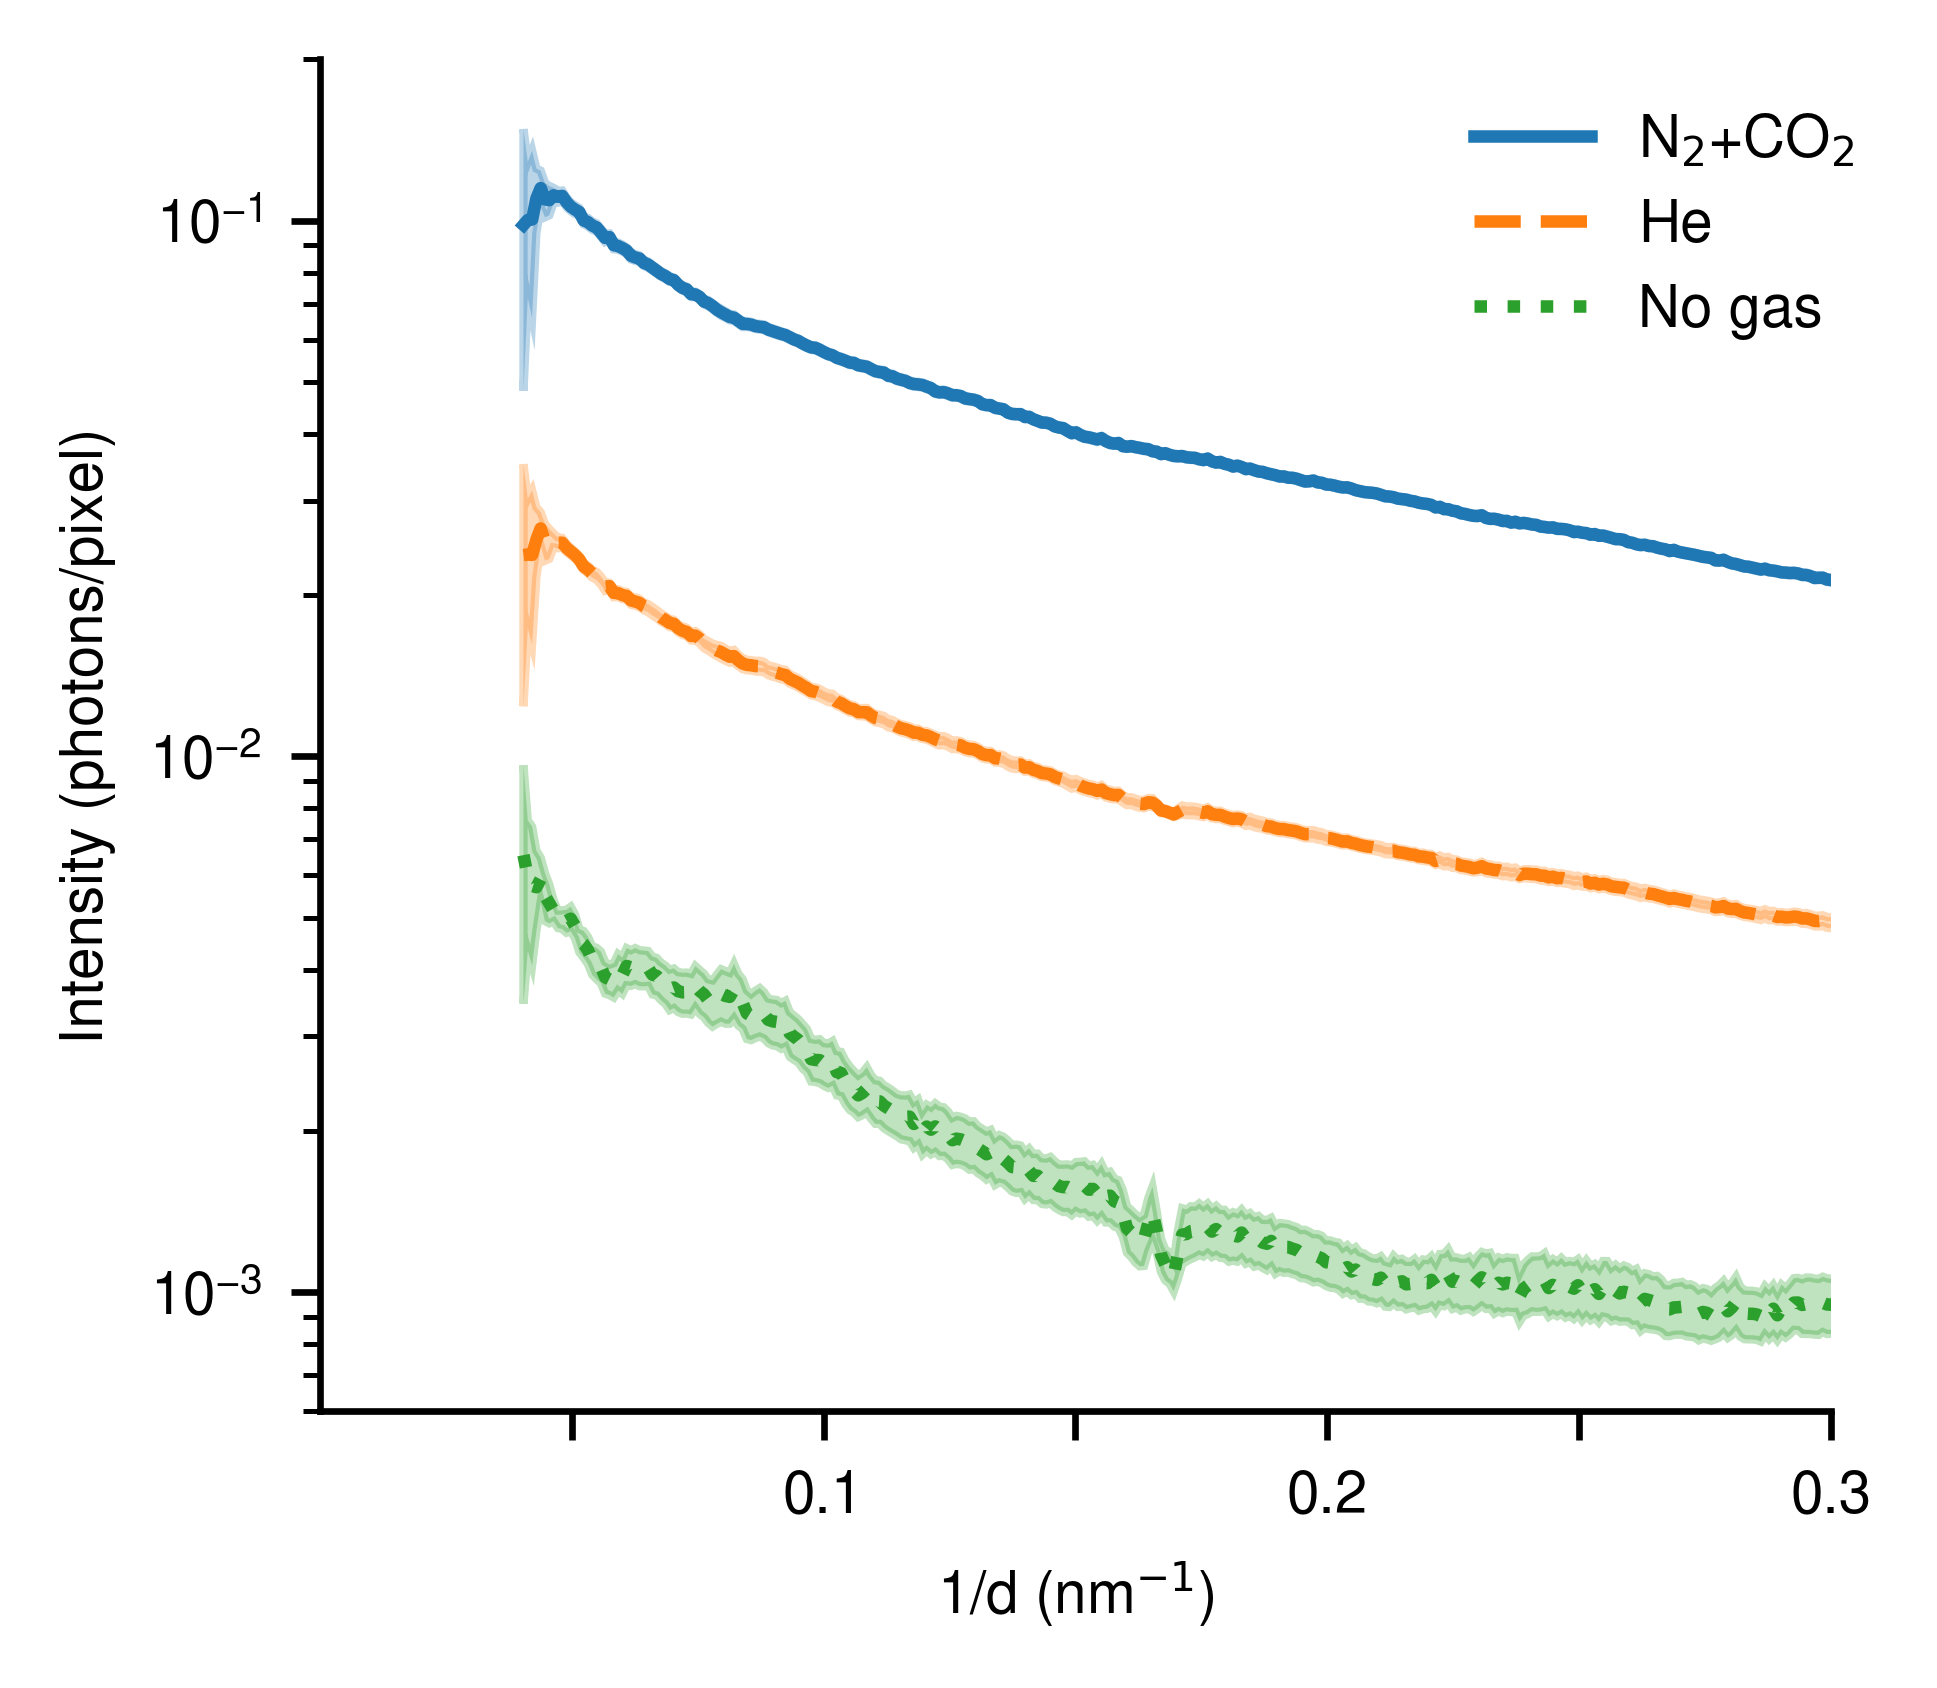

In [5]:
#Read radial averages
with h5py.File(f'./data/radav-r572.h5', 'r') as f:
    rbins = f['/rbins'][...]
    ngpix = f['/ngpix'][...]
    n2co2_radavg = f['/radavg'][...]
    n2co2_radstd = f['/radstd'][...]
    n2co2_radstd /= np.sqrt(ngpix)
    
with h5py.File(f'./data/radav-r571.h5', 'r') as f:
    n2co2he_radavg = f['/radavg'][...]
    n2co2he_radstd = f['/radstd'][...]
    n2co2he_radstd /= np.sqrt(ngpix)
    
with h5py.File(f'./data/radav-r574.h5', 'r') as f:
    nogas_radavg = f['/radavg'][...]
    nogas_radstd = f['/radstd'][...]
    nogas_radstd /= np.sqrt(ngpix)

nonnanloc = np.where(ngpix>0)

z=0.53 #detector position
lam=4.13 #wavelength
dpix=2e-4 #pixelsize


#calculate q units
r = rbins*dpix
theta2 = np.arctan2(r, z)
q = (4*np.pi/lam)*np.sin(0.5*theta2)


#figure settings
plt.rcParams.update({'font.size': 7})
plt.rcParams.update({"font.family":"sans-serif"})
plt.rcParams.update({"font.sans-serif":"Nimbus Sans"})
plt.rcParams.update({"pdf.fonttype":42})


plt.figure(figsize=(3.25,3.25), dpi=600)
#plot lines
plt.plot(q[nonnanloc], n2co2_radavg[nonnanloc], ls='solid', label='N$_2$+CO$_2$')
plt.plot(q[nonnanloc], n2co2he_radavg[nonnanloc], ls='dashed', label='He')
plt.plot(q[nonnanloc], nogas_radavg[nonnanloc], ls='dotted', label='No gas')

#plot error bounds (+/- 3std.)
bounds_xpts = list(q[nonnanloc])+list(q[nonnanloc][::-1])
bounds_ypts = list(n2co2_radavg[nonnanloc]+3*n2co2_radstd[nonnanloc])+ list(n2co2_radavg[nonnanloc][::-1]-3*n2co2_radstd[nonnanloc][::-1])
plt.fill(bounds_xpts, bounds_ypts, color="tab:blue", alpha=0.3)


bounds_xpts = list(q[nonnanloc])+list(q[nonnanloc][::-1])
bounds_ypts = list(n2co2he_radavg[nonnanloc]+3*n2co2he_radstd[nonnanloc])+ list(n2co2he_radavg[nonnanloc][::-1]-3*n2co2he_radstd[nonnanloc][::-1])
plt.fill(bounds_xpts, bounds_ypts, color="tab:orange", alpha=0.3)

bounds_xpts = list(q[nonnanloc])+list(q[nonnanloc][::-1])
bounds_ypts = list(nogas_radavg[nonnanloc]+3*nogas_radstd[nonnanloc])+ list(nogas_radavg[nonnanloc][::-1]-3*nogas_radstd[nonnanloc][::-1])
plt.fill(bounds_xpts, bounds_ypts, color="tab:green", alpha=0.3)


plt.yscale('log')
plt.xlabel('1/d (nm$^{-1}$)')
plt.ylabel('Intensity (photons/pixel)')
plt.xlim([0.0, 0.3])
plt.xticks([0.05, 0.1, 0.15, 0.2, 0.25, 0.3], ['', '0.1', '', '0.2', '', '0.3'])
plt.ylim([6e-4, 0.2])
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,
             box.width, box.height * 0.9])
ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.05, 1))
plt.savefig('./figs/gas_bg.png')
plt.savefig('./figs/gas_bg.svg', format='svg', bbox_inches='tight', dpi=600, transparent=True)

